In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ashydv/advertising-dataset",
    "advertising.csv"
)

print("First 5 records:")
print(df.head())

/tmp/ipykernel_1433/3824199503.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 3.97k/3.97k [00:00<00:00, 5.47MB/s]

First 5 records:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X = df[['TV']]
y = df['Sales']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))


Intercept: 7.007108428241848
Coefficient: 0.0554829439314632
MAE: 1.9502948931650088
MSE: 6.101072906773963
RMSE: 2.470035001123256
R2 Score: 0.802561303423698


In [ ]:
new_tv = [[200]]
prediction = model.predict(new_tv)

print("Predicted Sales for TV advertising = 200:", prediction[0])


Predicted Sales for TV advertising = 200: 18.10369721453449


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


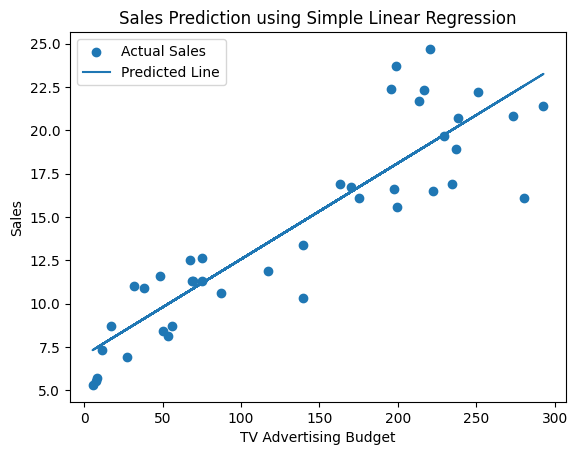

In [ ]:
plt.scatter(X_test, y_test, label="Actual Sales")
plt.plot(X_test, y_pred, label="Predicted Line")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("Sales Prediction using Simple Linear Regression")
plt.legend()
plt.show()